In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('creditcard.csv', nrows=20000)
df.head()

Saving creditcard.csv to creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df.shape)
print(df['Class'].value_counts())

(20000, 31)
Class
0    19915
1       85
Name: count, dtype: int64


In [5]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

# Undersampling
normal_sample = normal.sample(n=len(fraud))

new_df = pd.concat([normal_sample, fraud], axis=0)

print(new_df['Class'].value_counts())

Class
0    85
1    85
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X = new_df.drop('Class', axis=1)
y = new_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results[name] = score

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results[name] = score

In [10]:
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.93      0.96        14

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        14

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        14

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       

In [11]:
from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.93      0.96        14

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        14

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        14

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       

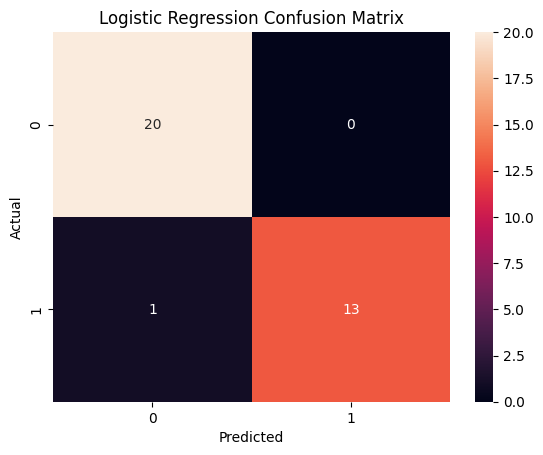

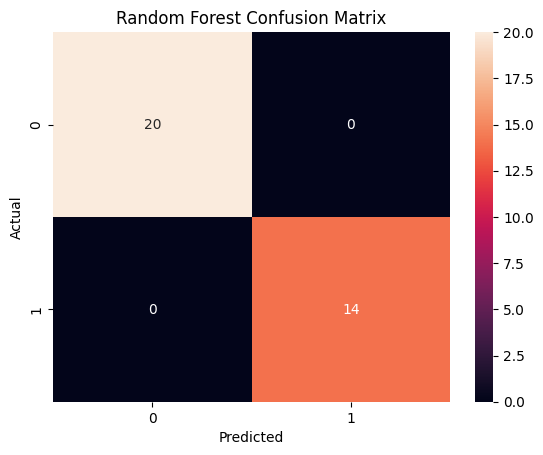

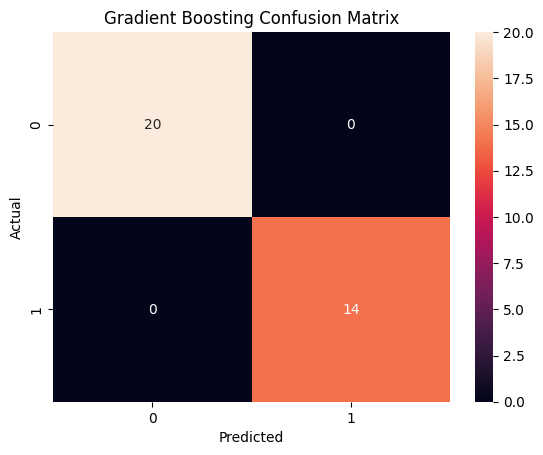

In [12]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

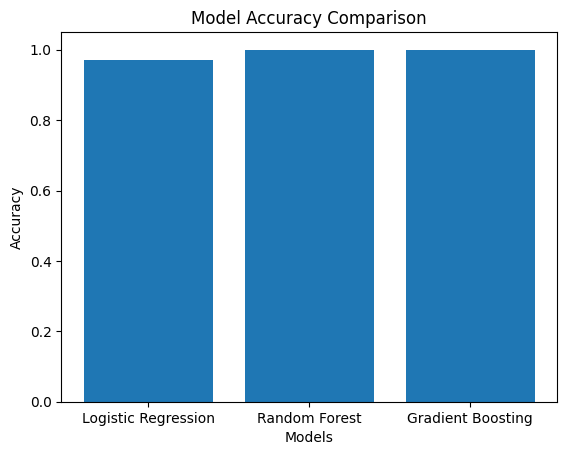

In [13]:
names = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(names, scores)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

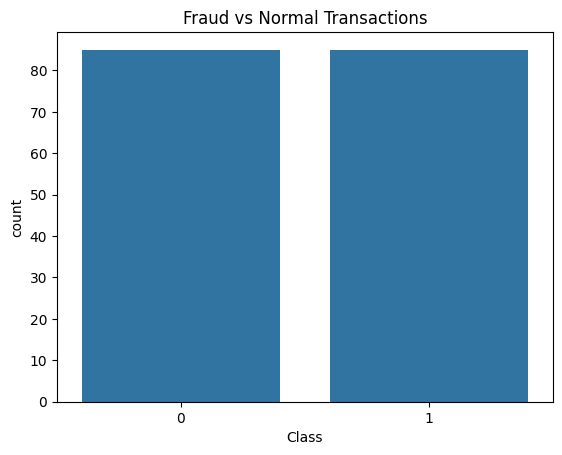

In [14]:
plt.figure()
sns.countplot(x='Class', data=new_df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [15]:
model.predict()

TypeError: GradientBoostingClassifier.predict() missing 1 required positional argument: 'X'

In [16]:
# Choose best model (example: Random Forest)
best_model = models["Random Forest"]

y_pred = best_model.predict(X_test)

print(y_pred[:20])  # first 20 predictions

[1 0 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1]


In [17]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,0,0


In [18]:
sample = X_test[0].reshape(1, -1)
prediction = best_model.predict(sample)

In [19]:
sample = X_test[0].reshape(1, -1)

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

Fraud Transaction 🚨


In [20]:
sample = X_test[5].reshape(1, -1)   # change index here

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

Fraud Transaction 🚨


In [ ]:
sample = X_test[90].reshape(1, -1)   # change index here

prediction = best_model.predict(sample)

if prediction[90] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

In [21]:
sample = X_test[90].reshape(1, -1)

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

IndexError: index 90 is out of bounds for axis 0 with size 34

In [22]:
sample = X_test[33].reshape(1, -1)

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction 🚨")
else:
    print("Normal Transaction ✅")

Fraud Transaction 🚨


In [23]:
print(len(X_test))

34


In [24]:
print(y_train.value_counts())

Class
1    71
0    65
Name: count, dtype: int64


In [25]:
normal = df[df['Class'] == 0].sample(n=5000)

In [26]:
print(len(X_test))

34


In [27]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(n=5000, random_state=42)

df_new = pd.concat([fraud, normal])
df_new = df_new.sample(frac=1, random_state=42)

In [28]:
X = df_new.drop('Class', axis=1)
y = df_new['Class']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
print(len(X_test))

1017


In [31]:
prob = best_model.predict_proba(sample)

print("Fraud Probability:", prob[0][1])

Fraud Probability: 0.99


In [32]:
for i in range(5):
    sample = X_test[i].reshape(1, -1)
    pred = best_model.predict(sample)

    print(f"Transaction {i}:",
          "Fraud 🚨" if pred[0]==1 else "Normal ✅")

KeyError: 0

In [33]:
y_prob = best_model.predict_proba(X_test)

# Fraud probability = column 1
fraud_probs = y_prob[:, 1]

# Get indices of LOW probability (normal)
normal_indices = np.where(fraud_probs < 0.2)[0]

print(normal_indices[:10])

[]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [34]:
y_prob = best_model.predict_proba(X_test)
fraud_probs = y_prob[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
model.fit(X_train, y_train)

In [35]:
sample = X_test.iloc[idx:idx+1]

NameError: name 'idx' is not defined

In [36]:
idx = 10  # change this value

sample = X_test.iloc[idx:idx+1]

prediction = best_model.predict(sample)

print("Actual:", y_test.values[idx])

if prediction[0] == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Predicted: Fraud 🚨


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [37]:
prob = best_model.predict_proba(sample)

print("Fraud Probability:", prob[0][1])

Fraud Probability: 0.64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [38]:
idx = 100  # change this value

sample = X_test.iloc[idx:idx+1]

prediction = best_model.predict(sample)

print("Actual:", y_test.values[idx])

if prediction[0] == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Predicted: Fraud 🚨


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [39]:
idx = 89  # change this value

sample = X_test.iloc[idx:idx+1]

prediction = best_model.predict(sample)

print("Actual:", y_test.values[idx])

if prediction[0] == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Predicted: Fraud 🚨


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [40]:
normal_indices = np.where(y_test.values == 0)[0]

print(normal_indices[:10])  # first 10 indices

[0 1 2 3 4 5 6 7 8 9]


In [41]:
idx = normal_indices[0]

sample = X_test.iloc[idx:idx+1]

prediction = best_model.predict(sample)

print("Actual:", y_test.values[idx])

if prediction[0] == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Predicted: Fraud 🚨


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [42]:
y_pred = best_model.predict(X_test)

correct_normal = np.where((y_test.values == 0) & (y_pred == 0))[0]

print(correct_normal[:10])

[ 90 123 124 191 299 347 386 414 415 541]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [43]:
idx = 90   # from your output

sample = X_test.iloc[idx:idx+1]

prediction = best_model.predict(sample)

print("Actual:", y_test.values[idx])

if prediction[0] == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Predicted: Normal ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [44]:
idx = 6   # from your output

sample = X_test.iloc[idx:idx+1]

prediction = best_model.predict(sample)

print("Actual:", y_test.values[idx])

if prediction[0] == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Predicted: Fraud 🚨


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [45]:
correct_fraud = np.where((y_test.values == 1) & (y_pred == 1))[0]

print(correct_fraud[:10])

[ 28 110 155 175 239 329 380 452 496 598]


In [46]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [47]:
normal = df[df['Class'] == 0].sample(n=20000)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [48]:
normal = df[df['Class'] == 0].sample(n=10000)

In [49]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.7).astype(int)

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      0.76      0.87        17

    accuracy                           1.00      1017
   macro avg       1.00      0.88      0.93      1017
weighted avg       1.00      1.00      1.00      1017



In [51]:
fp = ((y_test.values == 0) & (y_pred == 1)).sum()
print("False Positives:", fp)

False Positives: 0


In [52]:
fn = ((y_test.values == 1) & (y_pred == 0)).sum()
print("False Negatives:", fn)

False Negatives: 4


In [53]:
print("False Positives:", ((y_test.values == 0) & (y_pred == 1)).sum())
print("False Negatives:", ((y_test.values == 1) & (y_pred == 0)).sum())

False Positives: 0
False Negatives: 4


In [54]:
idx = 90

sample = X_test.iloc[idx:idx+1]

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > 0.7 else 0

print("Actual:", y_test.values[idx])
print("Probability:", prob)
print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

Actual: 0
Probability: 0.0
Predicted: Normal ✅


In [55]:
idx = 78

sample = X_test.iloc[idx:idx+1]

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > 0.7 else 0

print("Actual:", y_test.values[idx])
print("Probability:", prob)
print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

Actual: 0
Probability: 0.0
Predicted: Normal ✅


In [56]:
idx = 3

sample = X_test.iloc[idx:idx+1]

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > 0.7 else 0

print("Actual:", y_test.values[idx])
print("Probability:", prob)
print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

Actual: 0
Probability: 0.0
Predicted: Normal ✅


In [57]:
idx = 54

sample = X_test.iloc[idx:idx+1]

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > 0.7 else 0

print("Actual:", y_test.values[idx])
print("Probability:", prob)
print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

Actual: 0
Probability: 0.01
Predicted: Normal ✅


In [58]:
idx = 23

sample = X_test.iloc[idx:idx+1]

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > 0.7 else 0

print("Actual:", y_test.values[idx])
print("Probability:", prob)
print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

Actual: 0
Probability: 0.0
Predicted: Normal ✅


In [59]:
idx = 121

sample = X_test.iloc[idx:idx+1]

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > 0.7 else 0

print("Actual:", y_test.values[idx])
print("Probability:", prob)
print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

Actual: 0
Probability: 0.0
Predicted: Normal ✅


In [60]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')

# Balanced dataset
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(n=5000, random_state=42)

df_new = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_new.drop('Class', axis=1)
y = df_new['Class']

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [63]:
y_prob = model.predict_proba(X_test)[:, 1]

In [64]:
best_t = 0
best_score = 0

for t in np.arange(0.3, 0.8, 0.05):
    y_pred = (y_prob > t).astype(int)

    precision = ((y_test.values == 1) & (y_pred == 1)).sum() / max((y_pred == 1).sum(),1)
    recall = ((y_test.values == 1) & (y_pred == 1)).sum() / (y_test.values == 1).sum()

    score = precision + recall   # simple balance

    if score > best_score:
        best_score = score
        best_t = t

print("Best Threshold:", best_t)

Best Threshold: 0.44999999999999996


In [65]:
y_pred = (y_prob > best_t).astype(int)

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1001
           1       0.95      0.86      0.90        98

    accuracy                           0.98      1099
   macro avg       0.97      0.93      0.95      1099
weighted avg       0.98      0.98      0.98      1099

Confusion Matrix:
[[997   4]
 [ 14  84]]


In [67]:
fp = ((y_test.values == 0) & (y_pred == 1)).sum()
fn = ((y_test.values == 1) & (y_pred == 0)).sum()

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 4
False Negatives: 14


In [68]:
idx = 50  # change index

sample = X_test.iloc[idx].values.reshape(1, -1)

prob = model.predict_proba(sample)[0][1]
pred = 1 if prob > best_t else 0

print("Actual:", y_test.values[idx])
print("Fraud Probability:", prob)

if pred == 1:
    print("Predicted: Fraud 🚨")
else:
    print("Predicted: Normal ✅")

Actual: 0
Fraud Probability: 0.00911347019868226
Predicted: Normal ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [69]:
import random

indices = random.sample(range(len(X_test)), 10)

for idx in indices:
    sample = X_test.iloc[idx].values.reshape(1, -1)
    prob = model.predict_proba(sample)[0][1]
    pred = 1 if prob > best_t else 0

    print(f"\nIndex: {idx}")
    print("Actual:", y_test.values[idx])
    print("Prob:", round(prob,3))
    print("Predicted:", "Fraud 🚨" if pred==1 else "Normal ✅")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local


Index: 779
Actual: 0
Prob: 0.01
Predicted: Normal ✅

Index: 818
Actual: 0
Prob: 0.185
Predicted: Normal ✅

Index: 495
Actual: 0
Prob: 0.008
Predicted: Normal ✅

Index: 720
Actual: 0
Prob: 0.004
Predicted: Normal ✅

Index: 725
Actual: 0
Prob: 0.009
Predicted: Normal ✅

Index: 1083
Actual: 1
Prob: 1.0
Predicted: Fraud 🚨

Index: 915
Actual: 0
Prob: 0.007
Predicted: Normal ✅

Index: 327
Actual: 0
Prob: 0.012
Predicted: Normal ✅

Index: 1066
Actual: 0
Prob: 0.005
Predicted: Normal ✅

Index: 577
Actual: 0
Prob: 0.009
Predicted: Normal ✅


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [70]:
import ipywidgets as widgets
from IPython.display import display

# Input box
index_input = widgets.IntText(
    value=0,
    description='Index:',
)

# Button
button = widgets.Button(
    description='Check Transaction',
    button_style='success'
)

# Output area
output = widgets.Output()

# Button click function
def check_transaction(b):
    with output:
        output.clear_output()

        idx = index_input.value

        # safety check
        if idx >= len(X_test):
            print("❌ Index out of range")
            return

        sample = X_test.iloc[idx:idx+1]

        prob = model.predict_proba(sample)[0][1]
        pred = 1 if prob > best_t else 0

        print(f"Transaction Index: {idx}")
        print("Actual:", y_test.values[idx])
        print("Fraud Probability:", round(prob,3))

        if pred == 1:
            print("Predicted: Fraud 🚨")
        else:
            print("Predicted: Normal ✅")

# Connect button
button.on_click(check_transaction)

# Display UI
display(index_input, button, output)

IntText(value=0, description='Index:')

Button(button_style='success', description='Check Transaction', style=ButtonStyle())

Output()

In [71]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9836214740673339


In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1001
           1       0.95      0.86      0.90        98

    accuracy                           0.98      1099
   macro avg       0.97      0.93      0.95      1099
weighted avg       0.98      0.98      0.98      1099



In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[997   4]
 [ 14  84]]


In [75]:
!pip install nbformat

import nbformat

nb = nbformat.read("Untitled6.ipynb", as_version=4)

# Remove widget metadata
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbformat.write(nb, "clean_notebook.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'Untitled6.ipynb'

In [76]:
import os
print(os.listdir())

['.config', 'creditcard.csv', 'sample_data']
